In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

In [17]:
def eulers_method(xn, x0, y0, f, h=0.001):

    while xn > x0:
        y0 = y0 + h * f(x0, y0)
        x0 += h

    return y0

In [18]:
def RK4(xn, x0, y0, f, h=0.001):
    while xn > x0:

        h = h if (x0 + h <= xn) else (xn - x0)
        
        if h <= 1e-14:
            break

        k1 = h * f(x0, y0)
        k2 = h * f(x0 + h/2, y0 + k1/2)
        k3 = h * f(x0 + h/2, y0 + k2/2)
        k4 = h * f(x0 + h, y0 + k3)
        dy0 = (k1 + 2*k2 + 2*k3 + k4) / 6
        y0 = y0 + dy0
        x0 += h
        
    return y0

In [19]:
def RK2(xn, x0, y0, f, h=0.001):

    while xn > x0:
        k1 = h*f(x0, y0)
        y0 = y0 + h*f(x0 + h/2, y0 + k1/2)
        x0 += h
    
    return y0

### Zadanie 1

In [20]:
def ex1(x, y):
    return x**2 - 4*y

print(eulers_method(0.03, 0, 1, ex1))
print(RK4(0.03, 0, 1, ex1))
print(RK2(0.03, 0, 1, ex1))

0.8867153565877124
0.8869291730699764
0.8869294559228998


In [21]:
def analytical_ex1(x):
    return (31/32) * np.exp(-4*x) + (1/4)*x**2 - (1/8)*x + 1/32
print(analytical_ex1(0.03))

0.8869291730697463


### Zadanie 2

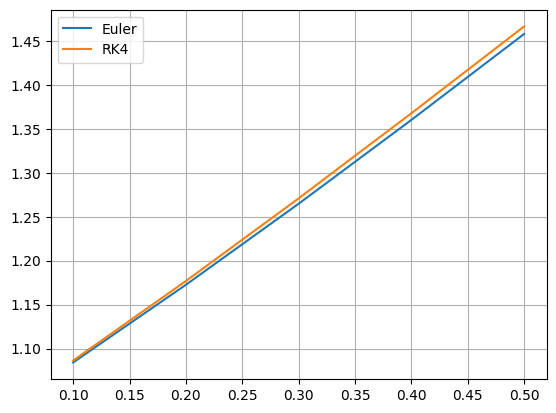

In [22]:
def ex2(x, y):
    return np.sin(y)
rk_list, euler_list = [], []
x_arg = [0.1, 0.2, 0.3, 0.4, 0.5]
for x in x_arg:

    y1 = eulers_method(x, 0, 1, ex2, 0.1)
    y2 = RK4(x, 0, 1, ex2, 0.1)

    euler_list.append(y1)
    rk_list.append(y2)

plt.plot(x_arg, euler_list, label="Euler")
plt.plot(x_arg, rk_list, label="RK4")
plt.grid()
plt.legend()
plt.show()

### Zadanie 3

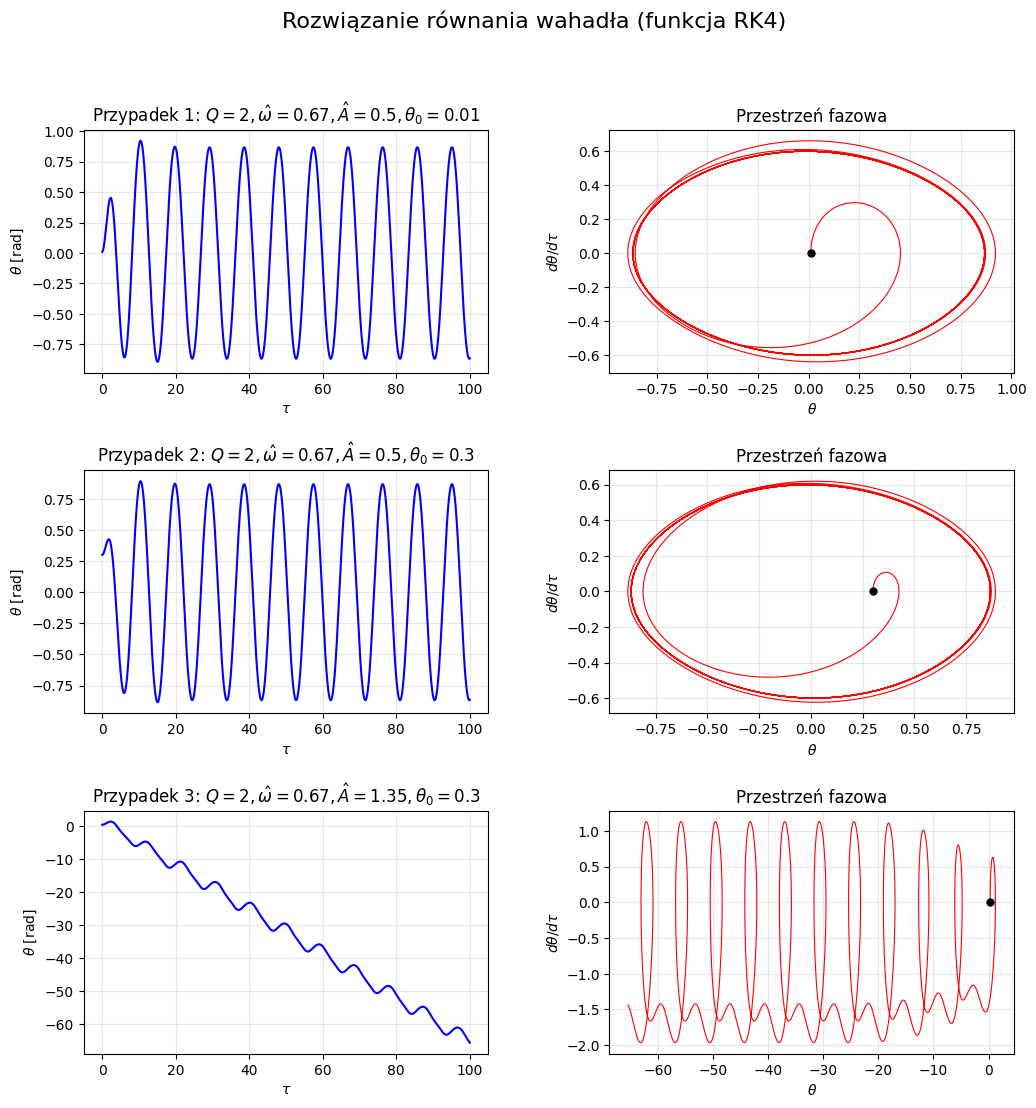

In [23]:
def pendulum_derivatives(tau, state, Q, A_hat, omega_hat):

    theta, dtheta_dtau = state
    dv_dtau = A_hat * np.cos(omega_hat * tau) - np.sin(theta) - (1/Q) * dtheta_dtau
    
    return np.array([dtheta_dtau, dv_dtau])

def solve_pendulum(Q, omega_hat, A_hat, v0, theta0, tau_max, dt):
    
    tau_values = [0]
    theta_values = [theta0]
    v_values = [v0]
    
    current_state = np.array([theta0, v0])
    current_tau = 0
    
    while current_tau < tau_max:
        target_tau = current_tau + dt
        
        def func_wrapper(t, y):
            return pendulum_derivatives(t, y, Q, A_hat, omega_hat)
        
        current_state = RK4(target_tau, current_tau, current_state, func_wrapper, dt)
        
        current_tau = target_tau
        
        tau_values.append(current_tau)
        theta_values.append(current_state[0])
        v_values.append(current_state[1])
        
    return np.array(tau_values), np.array(theta_values), np.array(v_values)

dt = 0.05
tau_max = 100

cases = [
    {"label": "Przypadek 1", "Q": 2, "w": 2/3, "A": 0.5, "v0": 0, "th0": 0.01},
    {"label": "Przypadek 2", "Q": 2, "w": 2/3, "A": 0.5, "v0": 0, "th0": 0.3},
    {"label": "Przypadek 3", "Q": 2, "w": 2/3, "A": 1.35, "v0": 0, "th0": 0.3}
]

fig, axes = plt.subplots(3, 2, figsize=(12, 12))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

for i, case in enumerate(cases):
    tau, theta, v = solve_pendulum(
        case["Q"], case["w"], case["A"], case["v0"], case["th0"], tau_max, dt
    )
    
    title_str = (f'{case["label"]}: $Q={case["Q"]}, \\hat{{\\omega}}={case["w"]:.2f}, '
                 f'\\hat{{A}}={case["A"]}, \\theta_0={case["th0"]}$')
    
    ax_time = axes[i, 0]
    ax_time.plot(tau, theta, color='blue')
    ax_time.set_title(title_str)
    ax_time.set_xlabel(r'$\tau$')
    ax_time.set_ylabel(r'$\theta$ [rad]')
    ax_time.grid(True, alpha=0.3)
    
    ax_phase = axes[i, 1]
    ax_phase.plot(theta, v, color='red', lw=0.8)
    ax_phase.set_title("Przestrzeń fazowa")
    ax_phase.set_xlabel(r'$\theta$')
    ax_phase.set_ylabel(r'$d\theta/d\tau$')
    ax_phase.grid(True, alpha=0.3)
    ax_phase.plot(theta[0], v[0], 'ko', markersize=5, label='Start')

plt.suptitle("Rozwiązanie równania wahadła (funkcja RK4)", fontsize=16)
plt.show()

### Zadanie 4

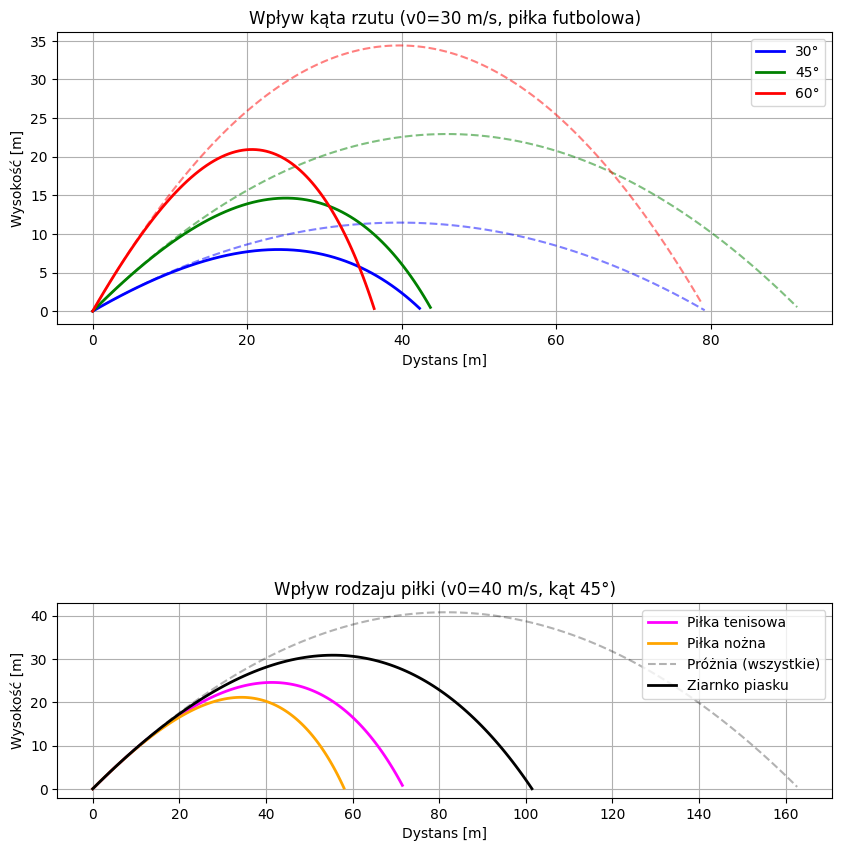

In [24]:
G = 9.81
RHO_AIR = 1.2
CW = 0.35

def derivatives(t, state, m, A, opor):
    x, y_pos, vx, vy = state
    
    v = np.sqrt(vx**2 + vy**2)
    
    ax = 0
    ay = -G
    
    if opor:
        const = 0.5 * CW * RHO_AIR * A
        ax = -(const / m) * v * vx
        ay = -G - (const / m) * v * vy
        
    return np.array([vx, vy, ax, ay])

def solve_trajectory(v0, kat_stopnie, r, m, opor):

    kat_rad = np.radians(kat_stopnie)
    vx0 = v0 * np.cos(kat_rad)
    vy0 = v0 * np.sin(kat_rad)
    A = np.pi * r**2
    
    state = np.array([0.0, 0.0, vx0, vy0])
    
    t = 0.0
    dt = 0.05
    
    x_hist = [state[0]]
    y_hist = [state[1]]
    
    while state[1] >= 0:
        def f_wrapper(t, y):
            return derivatives(t, y, m, A, opor)
        
        state = RK4(t + dt, t, state, f_wrapper, dt)
        
        t += dt
        
        if state[1] < 0:
            break
            
        x_hist.append(state[0])
        y_hist.append(state[1])
        
    return x_hist, y_hist

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12))
plt.subplots_adjust(hspace=0.3)

ax1.set_title("Wpływ kąta rzutu (v0=30 m/s, piłka futbolowa)")
m = 0.45
r = 0.11
v0 = 30
katy = [30, 45, 60]
kolory = ['blue', 'green', 'red']

for kat, kol in zip(katy, kolory):
    x, y = solve_trajectory(v0, kat, r, m, opor=False)
    ax1.plot(x, y, linestyle='--', color=kol, alpha=0.5)

    x, y = solve_trajectory(v0, kat, r, m, opor=True)
    ax1.plot(x, y, linestyle='-', color=kol, lw=2, label=f'{kat}°')

ax1.set_xlabel("Dystans [m]")
ax1.set_ylabel("Wysokość [m]")
ax1.legend()
ax1.grid(True)
ax1.set_aspect('equal')

ax2.set_title("Wpływ rodzaju piłki (v0=40 m/s, kąt 45°)")
v0_s2 = 40
kat_s2 = 45
pilki = [
    (0.03, 0.05, "Piłka tenisowa", "magenta"),
    (0.11, 0.45, "Piłka nożna", "orange"),
    (0.002, 0.0005, "Ziarnko piasku", "black") 
]

for r, m, nazwa, kol in pilki:
    x, y = solve_trajectory(v0_s2, kat_s2, r, m, opor=True)
    ax2.plot(x, y, color=kol, lw=2, label=nazwa)
    
    if nazwa == "Piłka nożna":
         x_ideal, y_ideal = solve_trajectory(v0_s2, kat_s2, r, m, opor=False)
         ax2.plot(x_ideal, y_ideal, 'k--', alpha=0.3, label='Próżnia (wszystkie)')

ax2.set_xlabel("Dystans [m]")
ax2.set_ylabel("Wysokość [m]")
ax2.legend()
ax2.grid(True)
ax2.set_aspect('equal')

plt.show()

### Zadanie 5

<>:41: SyntaxWarning: invalid escape sequence '\p'
<>:41: SyntaxWarning: invalid escape sequence '\p'
C:\Users\maja2\AppData\Local\Temp\ipykernel_9960\3332993610.py:41: SyntaxWarning: invalid escape sequence '\p'
  plt.plot(np.pi/2, 1, 'go', markersize=8, label='Cel: y($\pi$/2)=1')


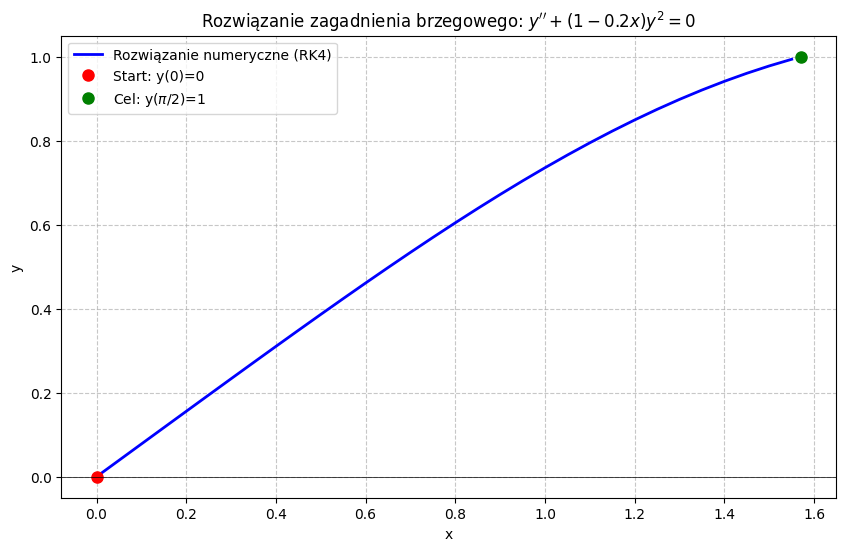

In [25]:
def derivatives(x, state):

    y, dy_dx = state  
    dy_prime_dx = -(1 - 0.2 * x) * (y**2)
    
    return np.array([dy_dx, dy_prime_dx])

def shoot(alpha):

    x_start = 0
    x_end = np.pi / 2
    y_start = 0 
    
    initial_state = np.array([y_start, alpha])
    
    final_state = RK4(x_end, x_start, initial_state, derivatives, h=0.01)
    
    return final_state[0] - 1.0

best_alpha = brentq(shoot, 0, 5)

x_plot = []
y_plot = []

x_current = 0
x_target = np.pi / 2
dt = 0.05
state = np.array([0.0, best_alpha])

while x_current <= x_target:
    x_plot.append(x_current)
    y_plot.append(state[0])
    
    state = RK4(x_current + dt, x_current, state, derivatives, dt)
    x_current += dt

plt.figure(figsize=(10, 6))
plt.plot(x_plot, y_plot, 'b-', linewidth=2, label='Rozwiązanie numeryczne (RK4)')

plt.plot(0, 0, 'ro', markersize=8, label='Start: y(0)=0')
plt.plot(np.pi/2, 1, 'go', markersize=8, label='Cel: y($\pi$/2)=1')

plt.title(r"Rozwiązanie zagadnienia brzegowego: $y'' + (1-0.2x)y^2 = 0$")
plt.xlabel("x")
plt.ylabel("y")
plt.axhline(0, color='black', linewidth=0.5)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()